1 4000


/share/home2/ebrahimis/project1_3_8/venv/lib/python3.8/site-packages/torch/nn/functional.py:1351: UserWarning: nn.functional.sigmoid is deprecated. Use torch.sigmoid instead.
  warnings.warn("nn.functional.sigmoid is deprecated. Use torch.sigmoid instead.")
/share/home2/ebrahimis/project1_3_8/oran/oran_enabled_mobility_aware_slicing/DRL_actual_size/radio_calc.py:534: RuntimeWarning: divide by zero encountered in log10
  self.signal_strength_dB[u] = 10 * np.log10(self.signal_strength)
/share/home2/ebrahimis/project1_3_8/oran/oran_enabled_mobility_aware_slicing/DRL_actual_size/radio_calc.py:538: RuntimeWarning: divide by zero encountered in log10
  self.SINR_dB[u] = 10 * np.log10(self.SINR)
/share/home2/ebrahimis/project1_3_8/oran/oran_enabled_mobility_aware_slicing/DRL_actual_size/radio_calc.py:532: RuntimeWarning: divide by zero encountered in log10
  self.interference_dB[u] = 10 * np.log10(I_inter)


error
-10
error
-10
error
-10
error
-10
error
-10
error
-10
error
-10
error
-10
error
-10
error
-10
NICE! Episode: 0, Timestep: 1058, Reward: 0.9214241318276134
NICE! Episode: 0, Timestep: 1070, Reward: 0.9103037547580114
NICE! Episode: 0, Timestep: 1137, Reward: 0.9291588512458496
NICE! Episode: 0, Timestep: 1193, Reward: 0.927428063092879
NICE! Episode: 0, Timestep: 1195, Reward: 0.9272213750274267
NICE! Episode: 0, Timestep: 1205, Reward: 0.9530217793885858
NICE! Episode: 0, Timestep: 1206, Reward: 0.9548428019656393
NICE! Episode: 0, Timestep: 1224, Reward: 0.9630313214224906
NICE! Episode: 0, Timestep: 1236, Reward: 0.9576050087499128
NICE! Episode: 0, Timestep: 1247, Reward: 0.9522286658773607
NICE! Episode: 0, Timestep: 1254, Reward: 0.9589754221459033
NICE! Episode: 0, Timestep: 1257, Reward: 0.944425236098641
NICE! Episode: 0, Timestep: 1268, Reward: 0.9450690030775092
NICE! Episode: 0, Timestep: 1271, Reward: 0.9393525051740933
NICE! Episode: 0, Timestep: 1287, Reward: 0.9362

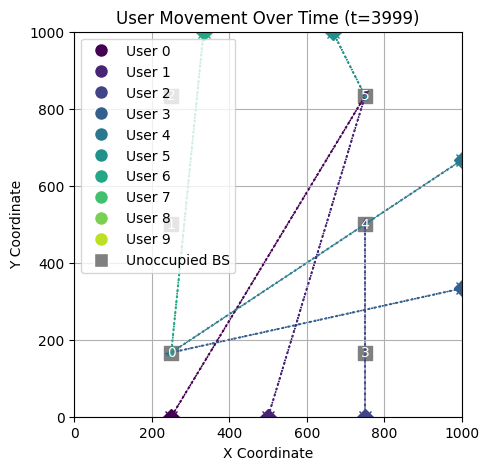

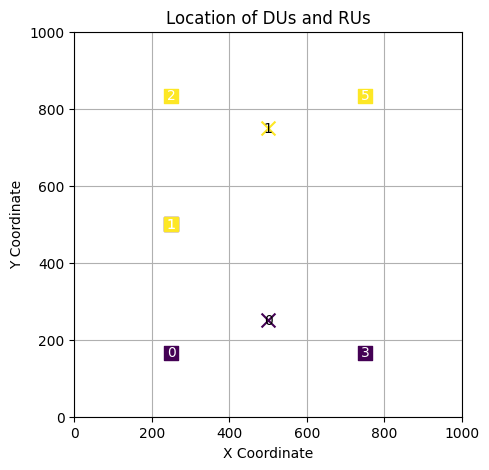

-------------
Runtime Duration:
-------------



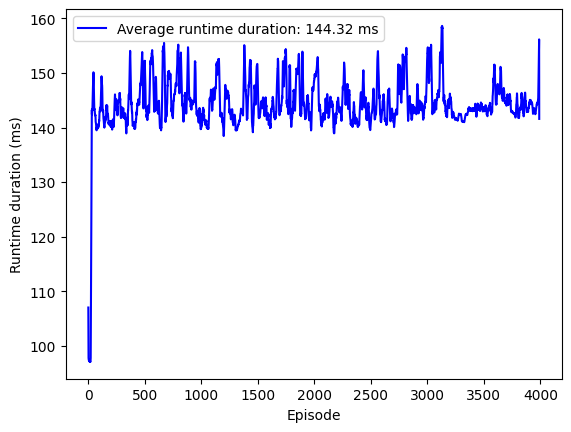

-------------
Avg PRBs used per user for SAC algorithm:
-------------



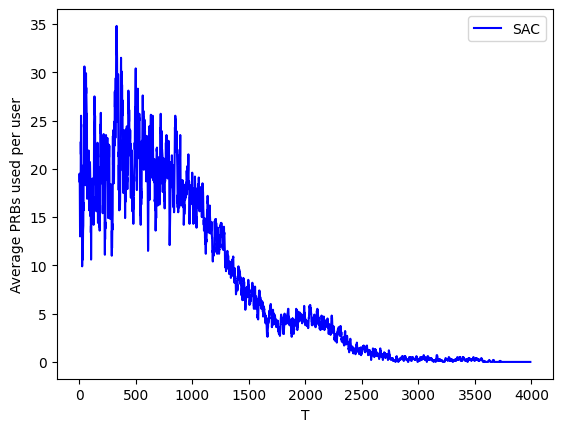

-------------
logarithmic rewards:
-------------



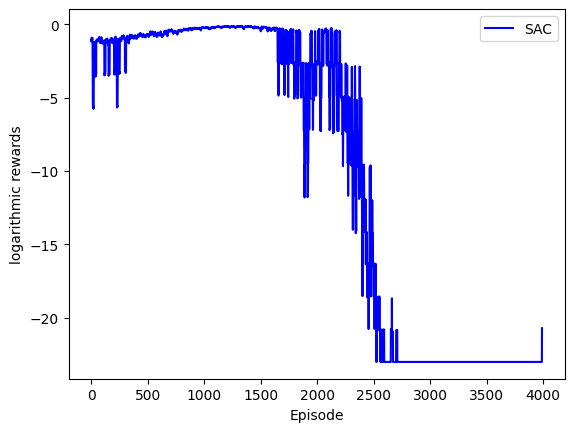

-------------
Mean episodic rewards:
-------------



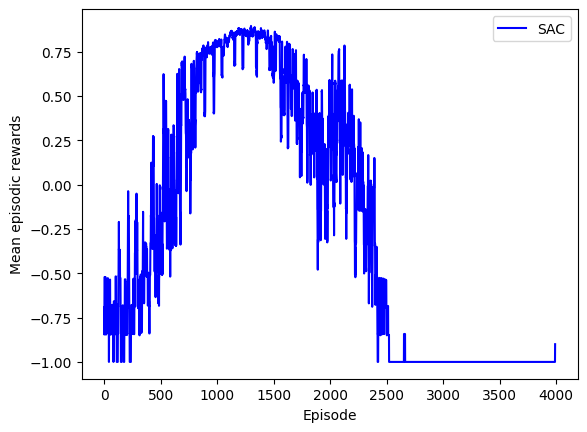

-------------
Constraint Satisfaction:
-------------



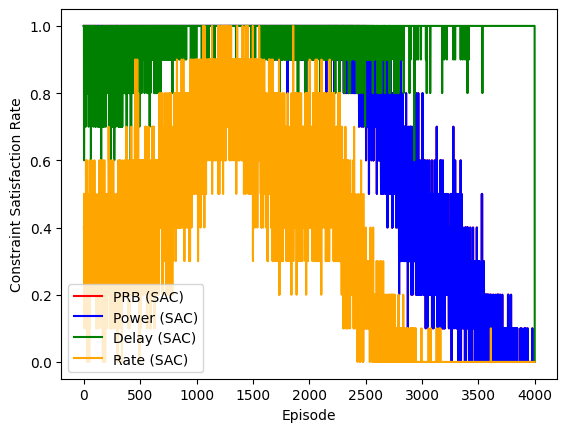

-------------
SSL Metrics:
-------------



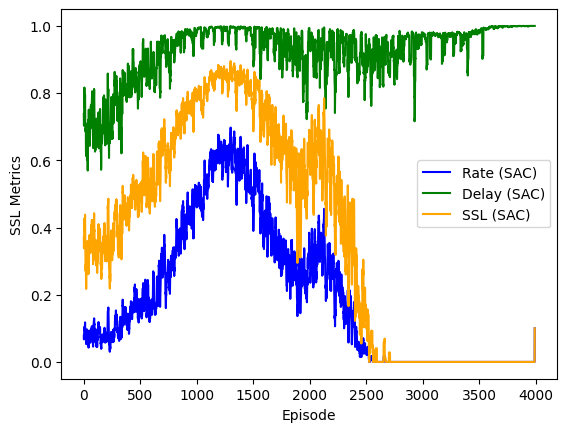

-------------
Comparison of Average E2E Delay (SAC):
-------------



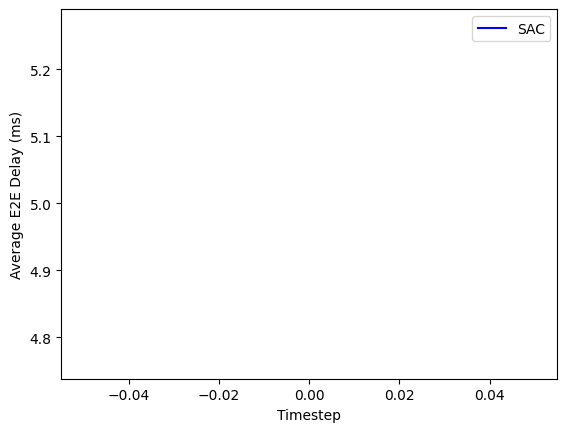

-------------
Average Data Rate (SAC):
-------------



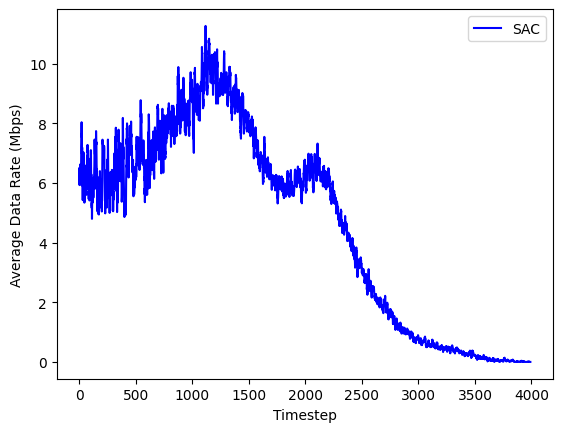

-------------
Average of total allocated power to each user (SAC):
-------------



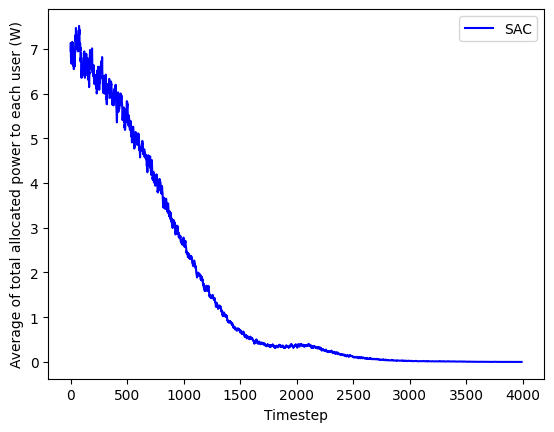

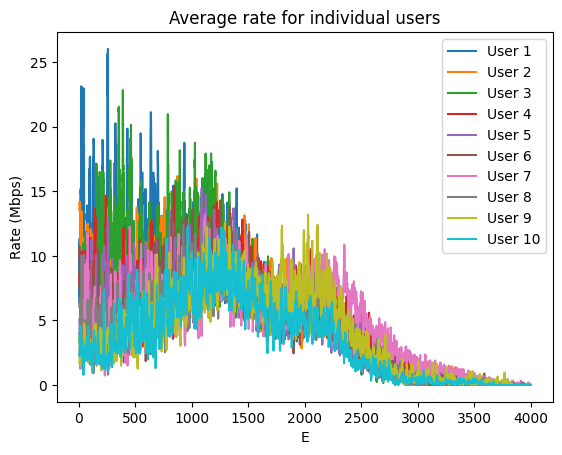

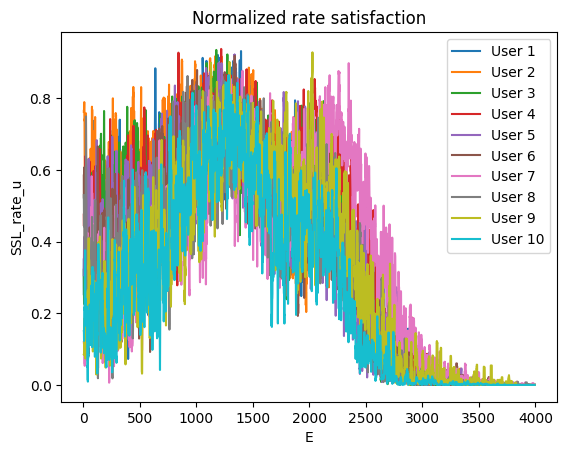

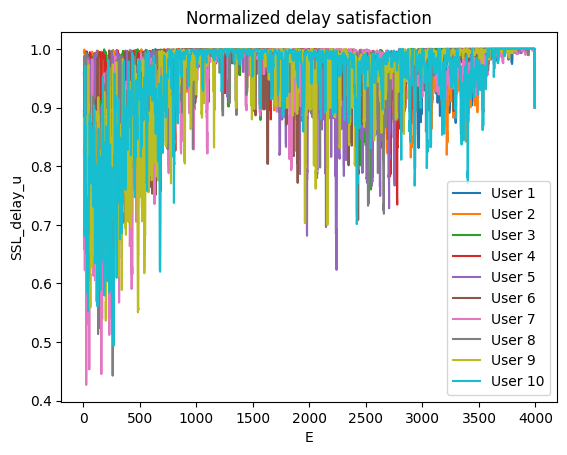

-------------
Sum of handovers :
-------------



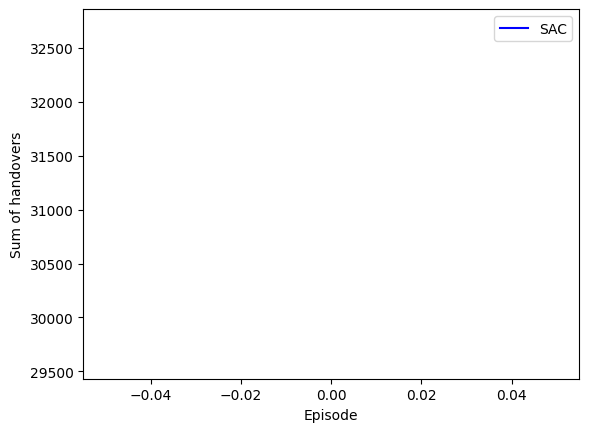

-------------
No. of satisfied delay and rate constraints (Max= 2*U):
-------------



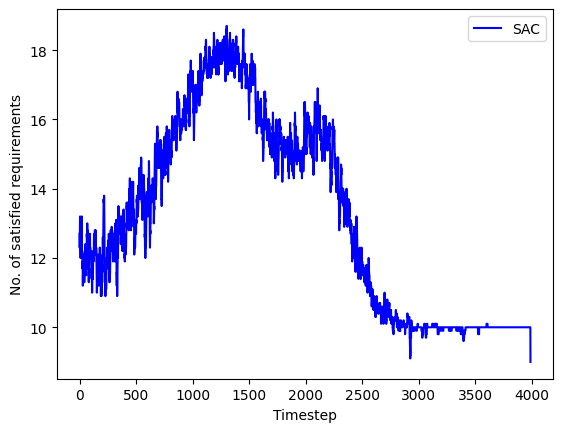

Total time for 4000 timesteps (10 users) in 1 Episdoes (aka iterations or epochs): 9.0 minutes 37.27444863319397 seconds


In [1]:
%run "main_constraint-based.py"

In [ ]:
group_size = 500
num_groups = T // group_size
avg_prbs_per_user = np.average(shannon, axis=1)

data = [avg_prbs_per_user[0, i*group_size:(i+1)*group_size] for i in range(num_groups)]

# Plotting
plt.figure(figsize=(12, 6))
plt.boxplot(data)
plt.xlabel('Groups of 100 Time steps')
plt.ylabel('Avg Rate (Mbps)')
plt.xticks(ticks=range(1, num_groups + 1), labels=[f'{i*group_size}-{(i+1)*group_size-1}' for i in range(num_groups)])
plt.show()

In [ ]:

window_size =50
average_rate = np.mean(shannon, axis=0)

for user_idx in range(USER_NO):
    plt.plot(moving_average(range(T), window_size), moving_average(average_rate[user_idx,:], window_size), label=f'User {user_idx+1}')
plt.xlabel('E')
plt.ylabel('Rate (Mbps)')
plt.title('Average rate for individual users')
plt.legend()
plt.show()

###
average_rate_ssl_u = np.mean(mat_fittingness_u_rate, axis=0)

for user_idx in range(USER_NO):
    plt.plot(moving_average(range(T), window_size), moving_average(average_rate_ssl_u[ user_idx,:], window_size), label=f'User {user_idx+1}')
plt.xlabel('E')
plt.ylabel('SSL_rate_u')
plt.title('Normalized rate satisfaction')
plt.legend()
plt.show()

###
average_delay_ssl_u = np.mean(mat_fittingness_u_delay, axis=0)

for user_idx in range(USER_NO):
    plt.plot(moving_average(range(T), window_size), moving_average(average_delay_ssl_u[user_idx,:], window_size), label=f'User {user_idx+1}')
plt.xlabel('E')
plt.ylabel('SSL_delay_u')
plt.title('Normalized delay satisfaction')
plt.legend()
plt.show()
###

In [ ]:

# Ignore the last time step
mat_reward = mat_satisfied_delay_constraint[:, :-1]

# Group data every 50 episodes
group_size = 500
num_groups = T // group_size
grouped_data = [mat_reward[0,i * group_size:(i + 1) * group_size].flatten() for i in range(num_groups)]

# Create a box plot for the grouped rewards

plt.figure(figsize=(10, 6))
plt.boxplot(grouped_data, vert=True, patch_artist=True)
plt.xlabel('Group of 20 Episodes')
plt.ylabel('Delay  constriant satisfaction (linear))')
plt.xticks(ticks=np.arange(1, num_groups + 1), labels=[f'{i*group_size}-{(i+1)*group_size-1}' for i in range(num_groups)])
plt.show()

# Ignore the last time step
mat_reward = mat_satisfied_rate_constraint[:, :-1]

# Group data every 50 episodes

grouped_data = [mat_reward[0,i * group_size:(i + 1) * group_size].flatten() for i in range(num_groups)]

# Create a box plot for the grouped rewards

plt.figure(figsize=(10, 6))
plt.boxplot(grouped_data, vert=True, patch_artist=True)
plt.xlabel('Timestep')
plt.ylabel('Bitrate constriant satisfaction (linear)')
plt.xticks(ticks=np.arange(1, num_groups + 1), labels=[f'{i*group_size}-{(i+1)*group_size-1}' for i in range(num_groups)])
plt.show()




####

# Ignore the last time step
mat_reward = mat_satisfied_prb_constraint[:, :-1]

# Group data every 50 episodes

grouped_data = [mat_reward[0,i * group_size:(i + 1) * group_size].flatten() for i in range(num_groups)]

# Create a box plot for the grouped rewards

plt.figure(figsize=(10, 6))
plt.boxplot(grouped_data, vert=True, patch_artist=True)
plt.xlabel('Timestep')
plt.ylabel('PRB constriant satisfaction (linear)')
plt.xticks(ticks=np.arange(1, num_groups + 1), labels=[f'{i*group_size}-{(i+1)*group_size-1}' for i in range(num_groups)])
plt.show()


# Ignore the last time step
mat_reward = mat_satisfied_power_constraint[:, :-1]

# Group data every 50 episodes

grouped_data = [mat_reward[0,i * group_size:(i + 1) * group_size].flatten() for i in range(num_groups)]

# Create a box plot for the grouped rewards

plt.figure(figsize=(10, 6))
plt.boxplot(grouped_data, vert=True, patch_artist=True)
plt.xlabel('Timestep')
plt.ylabel('Power constriant satisfaction (linear)')
plt.xticks(ticks=np.arange(1, num_groups + 1), labels=[f'{i*group_size}-{(i+1)*group_size-1}' for i in range(num_groups)])
plt.show()

# Ignore the last time step

In [ ]:
group_size = 500
num_groups = T // group_size

data = [mat_reward[0, i*group_size:(i+1)*group_size] for i in range(num_groups)]

# Plotting
plt.figure(figsize=(12, 6))
plt.boxplot(data)
plt.xlabel('Groups of 100 Time steps')
plt.ylabel('Reward')
plt.xticks(ticks=range(1, num_groups + 1), labels=[f'{i*group_size}-{(i+1)*group_size-1}' for i in range(num_groups)])
plt.show()

In [ ]:
avg_prbs_per_user = np.mean(mat_used_prbs_per_user, axis=(1))
mat_reward_excluded_last = avg_prbs_per_user[:,:-1]


# Ignore the last time step
# mat_reward = mat_reward[:, :-1]

# Group data every 50 episodes
group_size = 500
num_groups = T // group_size
grouped_data = [mat_reward_excluded_last[i * group_size:(i + 1) * group_size].flatten() for i in range(num_groups)]

# Create a box plot for the grouped rewards

plt.figure(figsize=(10, 6))
plt.boxplot(grouped_data, vert=True, patch_artist=True)
plt.xlabel('Group of 20 Episodes')
plt.ylabel('Avg number of PRBs per user')
# plt.title('Box Plot of PRB allocations Grouped by 50 Episodes')
plt.xticks(ticks=np.arange(1, num_groups + 1), labels=[f'{i*group_size}-{(i+1)*group_size-1}' for i in range(num_groups)])
plt.show()

In [ ]:
# config.yaml lstm
USER_NO: 8 #10 #20 # 4
BW: 180000  # %  180 kHz  (to be updated after consulting with Faouzi)
PRB_NO: 80 #  (to be updated after consulting with Faouzi)
SIGMA_NOISE: 10**(-17.4) #3.981e-18 # # = -174 dBm <tnsm23nouruzi> #
ETA_AREA: 3 # for rural areas according to TS 38.215 (Used in the Rayleigh/Distance formula for calculating data rate (Shannon)); equal to 3 for rural; 4 for urban areas # check also 38.913 for mobility scenarios and classes
X_LIM: 1000
Y_LIM: 1000
#CU_NO: 1 # only 1 CU is envisioned. It is co-located with the Near-RT RIC
DU_NO: 2 # all connected to the CU
RU_PER_DU_NO: 2 # Each DU has 4 RUs; Total number of RUs = 4*2 = 8
#BS_NO: 20 # should be equal to RU_PER_DU_NO*DU_NO # static for now; Location.bs_location() --- now it is bound to 4 BSs. Can be changed later
FH_BW_CAPACITY: 5000 # 100 Mbps in twc23kavehmadani# Mbps (5 Gbps) (link between RU and its DU) #
E2_BW_CAPACITY: 100000 # 5 Gbps in twc23kavehmadani #Mbps (100 Gbps) (link between DU and Near-RT RIC (equal to F1, which is between DU and CU))
#VM_NO: 9 # 6
#VNF_NO: 5 # 5
#NODE_NO: 12
SLICE_NO: 1 #5 # number of slice types ; will be indexed from 0 to (SLICE_NO - 1)
MAX_POWER: 40 # in watts ; equals to 46 dBm <tvt23choi> # 12 # (to be updated after consulting with Faouzi) # 46 dBm in tvt23choi = 40 watts (Much higher than normal papers)
OMEGA_1: 0.5 # to use in SSL weighting (for data rate term)
VELOCITY: 10 #0 #-1 means random #35 # m/s [5,20,35,50] #             = self.V ##################################################
CONST_D_MAX: 20 #-1 # ms
CONST_R_MIN: 5 #-1 # Mbps  
#ISOLATION_ORDER: -1
PACKET_SIZE: 0.012 # based on 1500 bytes for eMBB # in mbits # -1 # twc23kavehmadani: 1 KB for URLLC and 125 KB for eMBB
#PACKET_NO: 830  # 500 # -1 # packet generation rate per second # 0.012*500 = 6 Mbps # 0.012*830 = 9.96 Mbps
RAYLEIGH_SCALE: 1 # sigma in Rayleigh formula
#Episodes (T) and Number of monte-carlo runs:#
E: 4000 #1000# episodes/epochs for learning (the loop before T loop (replaces MC loop))
T: 100 #100# 14000 # 1000  6# Number of timeslots
#MC: 3  # Number of Monte-carlo runs
#Hyperparameters for the DRL algorithm
ALPHA_ACT: 0.00001 # 0.00001 # 0.00001 #0.000001 # actor's learning rate
BETA_ACT: 0.00005 # 0.00005 # 0.00005 # 0.000005 # Critic's learning rate
VAR: 1
DECAY_VAR: 0.9994 #95 #95 # .995 # can determine the ratio of exploration to exploitation
GAMMA: 0.5